In [7]:
import math
import hashlib
import random
import matplotlib.pyplot as plt

In [8]:
class CountMinSketch:
    def __init__(self, epsilon=None, delta=None, w=None, d=None):
        if epsilon is not None and delta is not None:
            self.w = math.ceil(math.e / epsilon)
            self.d = math.ceil(math.log(1 / delta))
        elif w is not None and d is not None:
            self.w = w
            self.d = d
        else:
            self.w = 2718
            self.d = 7
        
        self.counters = [[0] * self.w for _ in range(self.d)]
    
    def _hash(self, elem, i):
        salt = f"cms_row_{i}_seed_{i * 1000 + 42}".encode()
        h = hashlib.sha256(salt + str(elem).encode())
        hash_val = int(h.hexdigest(), 16)
        return hash_val % self.w
    
    def add(self, elem, count=1):
        for i in range(self.d):
            idx = self._hash(elem, i)
            self.counters[i][idx] += count
    
    def estimate(self, elem):
        return min(self.counters[i][self._hash(elem, i)] for i in range(self.d))
    
    def __add__(self, other):
        new_cms = CountMinSketch(w=self.w, d=self.d)
        for i in range(self.d):
            for j in range(self.w):
                new_cms.counters[i][j] = self.counters[i][j] + other.counters[i][j]
        return new_cms

=== ЗАПУСК БАЗОВЫХ ТЕСТОВ ===
Тест 1: Пустая CMS OK, оценка=0
Тест 2: Один элемент OK, оценка=10
Тест 3: Несколько элементов OK, оценки=5, 10, 15
Тест 4: Несуществующий элемент OK, оценка=0
Тест norm (n=250,000, ε=1e-05, δ=0.01):
  Запуски (3 раза): ['8.70%', '8.50%', '6.70%']
  Средняя погрешность: 7.97%
Тест big (n=1,150,000, ε=2e-06, δ=0.01):
  Запуски (3 раза): ['5.60%', '6.40%', '6.90%']
  Средняя погрешность: 6.30%

=== Тест объединения CMS (3.3) ===
Погрешность объединённой структуры: 0.00%
  ε=0.001, w=2719: Погрешность=45.80%
  ε=0.0005, w=5437: Погрешность=8.27%
  ε=0.0002, w=13592: Погрешность=0.33%
  ε=0.0001, w=27183: Погрешность=0.07%
  ε=5e-05, w=54366: Погрешность=0.00%


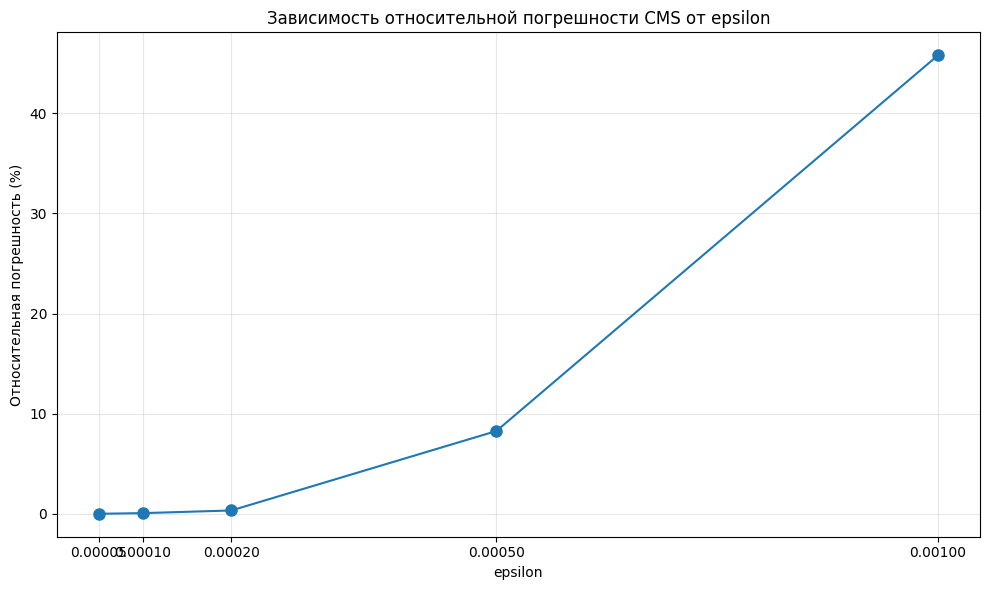

  δ=0.1, d=3: Погрешность=0.60%
  δ=0.05, d=3: Погрешность=0.60%
  δ=0.01, d=5: Погрешность=0.07%
  δ=0.005, d=6: Погрешность=0.00%
  δ=0.001, d=7: Погрешность=0.00%


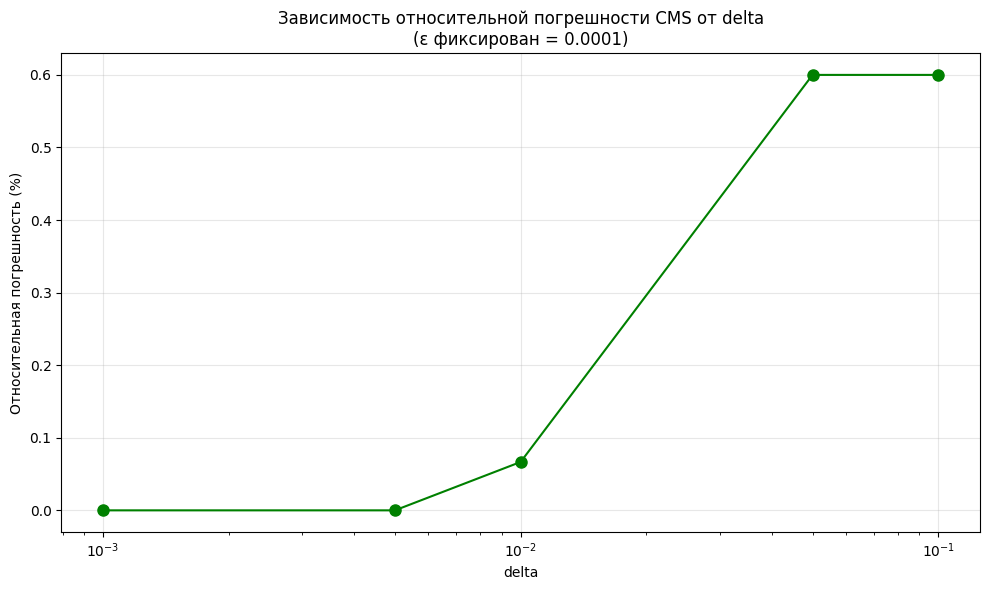

In [9]:
def stream_generator(seed=None):
    if seed is not None:
        random.seed(seed)
    while True:
        yield f"data_{random.randint(0, 10**9)}"

def test_empty_cms():
    cms = CountMinSketch(w=1000, d=5)
    est = cms.estimate("test")
    assert est == 0, f"Пустая CMS: ожидалось 0, получено {est}"
    print(f"Тест 1: Пустая CMS OK, оценка={est}")


def test_single_element():
    cms = CountMinSketch(w=1000, d=5)
    cms.add("elem1", 10)
    est = cms.estimate("elem1")
    assert est == 10, f"Один элемент: ожидалось 10, получено {est}"
    print(f"Тест 2: Один элемент OK, оценка={est}")


def test_multiple_elements():
    cms = CountMinSketch(w=1000, d=5)
    cms.add("elem1", 5)
    cms.add("elem2", 10)
    cms.add("elem3", 15)
    
    est1 = cms.estimate("elem1")
    est2 = cms.estimate("elem2")
    est3 = cms.estimate("elem3")
    
    assert est1 >= 5, f"elem1: оценка {est1} < 5"
    assert est2 >= 10, f"elem2: оценка {est2} < 10"
    assert est3 >= 15, f"elem3: оценка {est3} < 15"
    print(f"Тест 3: Несколько элементов OK, оценки={est1}, {est2}, {est3}")


def test_nonexistent_element():
    cms = CountMinSketch(w=1000, d=5)
    cms.add("elem1", 100)
    est = cms.estimate("nonexistent")
    assert est <= 100, f"Несуществующий элемент: оценка {est} > 100"
    print(f"Тест 4: Несуществующий элемент OK, оценка={est}")


def test_error_evaluation(n_total, epsilon, delta, config_name):
    runs = 3
    error_rates = []
    
    for run in range(runs):
        cms = CountMinSketch(epsilon=epsilon, delta=delta)
        gen = stream_generator(seed=run)
        
        elements = []
        for _ in range(n_total):
            elem = next(gen)
            cms.add(elem, 1)
            elements.append(elem)
        
        sample_size = min(1000, n_total)
        total_error = 0
        
        for i in range(sample_size):
            true_count = 1
            est_count = cms.estimate(elements[i])
            error = abs(est_count - true_count) / true_count
            total_error += error
        
        avg_error = total_error / sample_size
        error_rates.append(avg_error)
    
    avg_error = sum(error_rates) / len(error_rates)
    
    print(f"Тест {config_name} (n={n_total:,}, ε={epsilon}, δ={delta}):")
    print(f"  Запуски ({runs} раза): {[f'{e*100:.2f}%' for e in error_rates]}")
    print(f"  Средняя погрешность: {avg_error*100:.2f}%")
    
    assert avg_error < 0.1, f"Погрешность {avg_error*100:.2f}% > 10%"
    
    return avg_error


def test_cms_merge():
    print("\n=== Тест объединения CMS (3.3) ===")
    
    epsilon = 0.0001
    delta = 0.01
    n_elements = 5000
    
    cms1 = CountMinSketch(epsilon=epsilon, delta=delta)
    cms2 = CountMinSketch(epsilon=epsilon, delta=delta)
    
    gen1 = stream_generator(seed=100)
    gen2 = stream_generator(seed=200)
    
    elements1 = []
    elements2 = []
    
    for _ in range(n_elements):
        e1 = next(gen1)
        e2 = next(gen2)
        cms1.add(e1, 1)
        cms2.add(e2, 1)
        elements1.append(e1)
        elements2.append(e2)
    
    cms_merged = cms1 + cms2
    
    errors = []
    for elem in elements1[:500]:
        est = cms_merged.estimate(elem)
        error = abs(est - 1) / 1 * 100
        errors.append(error)
    
    avg_error = sum(errors) / len(errors)
    print(f"Погрешность объединённой структуры: {avg_error:.2f}%")
    
    return avg_error


def plot_epsilon_error_dependency():
    rel_errors = []
    epsilons = [0.001, 0.0005, 0.0002, 0.0001, 0.00005]
    n = 5000
    delta = 0.01
    runs = 3
    
    for epsilon in epsilons:
        run_errors = []
        
        for run in range(runs):
            cms = CountMinSketch(epsilon=epsilon, delta=delta)
            gen = stream_generator(seed=run)
            
            elements = []
            for _ in range(n):
                elem = next(gen)
                cms.add(elem, 1)
                elements.append(elem)
            
            sample_size = min(500, n)
            total_error = 0
            
            for i in range(sample_size):
                est = cms.estimate(elements[i])
                error = abs(est - 1) / 1 * 100
                total_error += error
            
            avg_error = total_error / sample_size
            run_errors.append(avg_error)
        
        avg_error = sum(run_errors) / len(run_errors)
        rel_errors.append(avg_error)
        w = math.ceil(math.e / epsilon)
        print(f"  ε={epsilon}, w={w}: Погрешность={avg_error:.2f}%")
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    ax.plot(epsilons, rel_errors, 'o-', markersize=8)
    ax.set_xlabel('epsilon')
    ax.set_ylabel('Относительная погрешность (%)')
    ax.set_title('Зависимость относительной погрешности CMS от epsilon')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(epsilons)
    
    plt.tight_layout()
    plt.show()

def plot_delta_error_dependency():
    rel_errors = []
    deltas = [0.1, 0.05, 0.01, 0.005, 0.001]
    epsilon = 0.0001
    n = 5000
    runs = 3
    
    for delta in deltas:
        run_errors = []
        
        for run in range(runs):
            cms = CountMinSketch(epsilon=epsilon, delta=delta)
            gen = stream_generator(seed=run)
            
            elements = []
            for _ in range(n):
                elem = next(gen)
                cms.add(elem, 1)
                elements.append(elem)
            
            sample_size = min(500, n)
            total_error = 0
            
            for i in range(sample_size):
                est = cms.estimate(elements[i])
                error = abs(est - 1) / 1 * 100
                total_error += error
            
            avg_error = total_error / sample_size
            run_errors.append(avg_error)
        
        avg_error = sum(run_errors) / len(run_errors)
        rel_errors.append(avg_error)
        d = math.ceil(math.log(1 / delta))
        print(f"  δ={delta}, d={d}: Погрешность={avg_error:.2f}%")
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    ax.plot(deltas, rel_errors, 'o-', markersize=8, color='green')
    ax.set_xlabel('delta')
    ax.set_ylabel('Относительная погрешность (%)')
    ax.set_title('Зависимость относительной погрешности CMS от delta\n(ε фиксирован = 0.0001)')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(deltas)
    ax.set_xscale('log')
    
    plt.tight_layout()
    plt.show()


def run_all_cms_tests():
    print("=== ЗАПУСК БАЗОВЫХ ТЕСТОВ ===")
    test_empty_cms()
    test_single_element()
    test_multiple_elements()
    test_nonexistent_element()
    
    test_error_evaluation(250_000, 0.00001, 0.01, "norm")
    test_error_evaluation(1_150_000, 0.000002, 0.01, "big")
    
    test_cms_merge()
    
    plot_epsilon_error_dependency()
    plot_delta_error_dependency()


if __name__ == "__main__":
    run_all_cms_tests()